# Partie 4 - Restitution Finale

Notebook redige en vue d'un export PDF. L'objectif est de fournir une restitution complete, argumentee et exploitable pour la prise de decision RH.


In [7]:
from pathlib import Path
import importlib
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import hr_analysis_utils as utils
importlib.reload(utils)

MahalanobisAnomalyDetector = utils.MahalanobisAnomalyDetector
random_oversample_minority = utils.random_oversample_minority
SimpleLogisticRegression = utils.SimpleLogisticRegression
attrition_by_group = utils.attrition_by_group
attrition_gap_summary = utils.attrition_gap_summary
coefficient_importance = utils.coefficient_importance
correlation_with_attrition = utils.correlation_with_attrition
dataset_overview = utils.dataset_overview
kpi_table = utils.kpi_table
load_data = utils.load_data
missing_summary = utils.missing_summary
numeric_summary = utils.numeric_summary
plot_bar = utils.plot_bar
plot_box_by_attrition = utils.plot_box_by_attrition
plot_correlation_heatmap = utils.plot_correlation_heatmap
plot_histogram = utils.plot_histogram
plot_top_coefficients = utils.plot_top_coefficients
prepare_model_data = utils.prepare_model_data
prepare_numeric_anomaly_data = utils.prepare_numeric_anomaly_data
pr_auc_score_manual = utils.pr_auc_score_manual
roc_auc_score_manual = utils.roc_auc_score_manual
salary_gap_by_gender = utils.salary_gap_by_gender
average_by_group = utils.average_by_group
top_attrition_segments = utils.top_attrition_segments
find_best_threshold = utils.find_best_threshold
classification_metrics = utils.classification_metrics

DATA_PATH = PROJECT_ROOT / "raw" / "people_analytics_dataset.csv"
df = load_data(DATA_PATH)
pd.set_option("display.max_columns", 100)


## Contexte

La DRH souhaite mieux comprendre les dynamiques de depart, d'engagement, d'evolution de carriere, de remuneration et de mobilite interne au sein d'une entreprise internationale d'environ 8 000 collaborateurs.

Le dataset analyse contient **8 020 collaborateurs** et **28 variables**. L'objectif etait double :

1. transformer les donnees RH en indicateurs de pilotage
2. construire un premier modele de prediction de l'attrition


## Faits marquants de l'EDA et de l'analyse RH

### 1. Une attrition globalement faible mais non homogene

- Le taux d'attrition global s'etablit a **2,59 %**.
- Les niveaux les plus eleves apparaissent en **France (3,81 %)** et dans le **departement IT (2,89 %)**.
- Le niveau de teletravail **75 %** ressort egalement comme une modalite plus exposee dans ce dataset.

### 2. L'engagement et la securite psychologique jouent un role de fond

- Les collaborateurs partis ont un **engagement plus faible** que les collaborateurs restes.
- Leur **securite psychologique** est egalement plus basse.
- Les populations avec engagement faible affichent un taux d'attrition superieur aux autres groupes.

### 3. Les conditions de travail donnent des signaux complementaires

- Les collaborateurs partis presentent un peu plus d'**absenteisme** et d'**heures supplementaires**.
- Ils ont aussi recu **moins de formation** en moyenne.

### 4. Carriere, mobilite et remuneration

- Environ **24,64 %** des collaborateurs ont eu une promotion sur 3 ans.
- La **mobilite interne** concerne **63,72 %** des collaborateurs au moins une fois.
- Le **salaire moyen** est de **62 313** par an, avec une progression nette selon le niveau hierarchique.
- Un ecart brut apparait entre salaire moyen des femmes et des hommes, ce qui justifie une analyse plus fine par poste, pays et niveau.


In [8]:
kpi_table(df)


,KPI,Valeur
0,Effectif total,8020.00
1,Taux d'attrition (%),2.59
2,Score d'engagement moyen,68.15
3,Score de securite psychologique moyen,66.19
4,Taux de promotion sur 3 ans (%),24.64
5,Taux de mobilite interne (%),63.72
6,Heures de formation moyennes,34.64
7,Absenteisme moyen (jours),6.93
8,Heures supp. moyennes,19.55
9,Salaire moyen annuel,62313.28


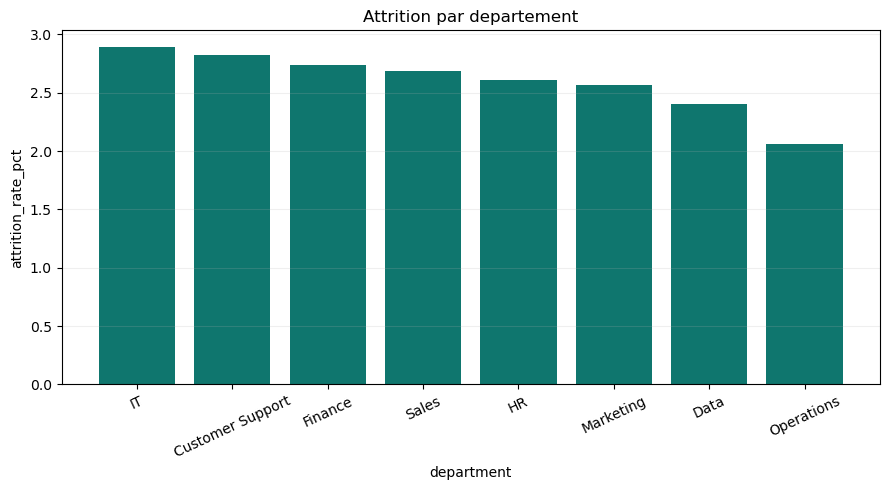

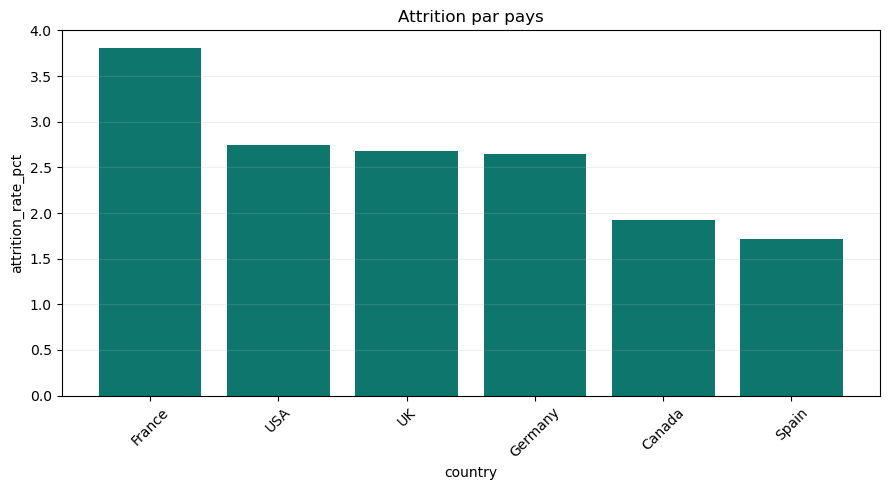

In [9]:
plot_bar(attrition_by_group(df, "department"), "department", "attrition_rate_pct", title="Attrition par departement", rotation=25)
plot_bar(attrition_by_group(df, "country"), "country", "attrition_rate_pct", title="Attrition par pays")


## Resultats du modele predictif

Le modele retenu est une regression logistique interpretable. Il a ete entraine sur des donnees nettoyees et encodees, avec ponderation des classes pour compenser la rarete des departs.


In [10]:
prepared = prepare_model_data(df, drop_columns=["employee_id"])
model = SimpleLogisticRegression(learning_rate=0.05, epochs=4000, reg_strength=0.02, class_weight="balanced")
model.fit(prepared.X_train, prepared.y_train)
best_threshold = find_best_threshold(prepared.y_val, model.predict_proba(prepared.X_val))
test_scores = model.predict_proba(prepared.X_test)
test_metrics = classification_metrics(prepared.y_test, test_scores, threshold=best_threshold["threshold"])

pd.DataFrame(
    [
        ("ROC-AUC", roc_auc_score_manual(prepared.y_test, test_scores)),
        ("PR-AUC", pr_auc_score_manual(prepared.y_test, test_scores)),
        ("Recall", test_metrics["recall"]),
        ("Precision", test_metrics["precision"]),
        ("F1-score", test_metrics["f1_score"]),
    ],
    columns=["Metrique", "Valeur"],
).round(4)


,Metrique,Valeur
0,ROC-AUC,0.5951
1,PR-AUC,0.0358
2,Recall,0.0476
3,Precision,0.0244
4,F1-score,0.0323


In [11]:
coefficient_importance(model, prepared.feature_names, top_n=15)


,feature,coefficient,abs_coefficient,odds_ratio
52,job_role_ML Engineer,-0.7508,0.7508,0.4720
2,contracted_hours_weekly,-0.3628,0.3628,0.6957
8,training_hours,-0.3038,0.3038,0.7380
16,salary,-0.2979,0.2979,0.7424
12,overtime_hours,0.2585,0.2585,1.2950
11,absenteeism_days,0.2563,0.2563,1.2922
15,psychological_safety_score,-0.2535,0.2535,0.7761
49,job_role_Frontend Developer,0.2440,0.2440,1.2764
84,overtime_band_26+,-0.2314,0.2314,0.7934
44,job_role_Data Analyst,0.2234,0.2234,1.2503


### Interpretation

- Les performances du modele restent **modestes**. Il identifie un signal, mais insuffisant pour une decision individuelle fiable.
- Les variables les plus contributives vont dans le sens des analyses descriptives : **formation**, **securite psychologique**, **salaire** et **absenteisme** participent au signal.
- Ce resultat est coherent avec un contexte RH ou les departs sont rares et probablement influences par des facteurs non captures dans le dataset.


## Experience complementaire : detection d'anomalie

Une approche alternative a ete testee pour tenir compte de la faible representation de l'attrition : la **detection d'anomalie**. L'idee consiste a apprendre le profil "habituel" des collaborateurs qui restent, puis a identifier les profils qui s'en ecartent le plus.


In [12]:
numeric_data = prepare_numeric_anomaly_data(df, drop_columns=["employee_id"])
anomaly_model = MahalanobisAnomalyDetector(regularization=0.1)
anomaly_model.fit(numeric_data.X_train[numeric_data.y_train == 0])
anomaly_val_scores = anomaly_model.score_samples(numeric_data.X_val)
anomaly_thresholds = np.quantile(anomaly_val_scores, np.linspace(0.70, 0.99, 60))
anomaly_best_threshold = find_best_threshold(
    numeric_data.y_val,
    anomaly_val_scores,
    thresholds=np.unique(anomaly_thresholds),
)
anomaly_test_scores = anomaly_model.score_samples(numeric_data.X_test)
anomaly_metrics = classification_metrics(
    numeric_data.y_test,
    anomaly_test_scores,
    threshold=anomaly_best_threshold["threshold"],
)

oversample = random_oversample_minority(prepared.X_train, prepared.y_train, seed=42)
oversampled_model = SimpleLogisticRegression(
    learning_rate=0.05,
    epochs=4000,
    reg_strength=0.02,
    class_weight=None,
)
oversampled_model.fit(oversample.X_resampled, oversample.y_resampled)
oversampled_best_threshold = find_best_threshold(
    prepared.y_val,
    oversampled_model.predict_proba(prepared.X_val),
)
oversampled_test_scores = oversampled_model.predict_proba(prepared.X_test)
oversampled_metrics = classification_metrics(
    prepared.y_test,
    oversampled_test_scores,
    threshold=oversampled_best_threshold["threshold"],
)

pd.DataFrame(
    [
        (
            "Regression logistique ponderee",
            roc_auc_score_manual(prepared.y_test, test_scores),
            pr_auc_score_manual(prepared.y_test, test_scores),
            test_metrics["recall"],
            test_metrics["f1_score"],
        ),
        (
            "Random oversampling",
            roc_auc_score_manual(prepared.y_test, oversampled_test_scores),
            pr_auc_score_manual(prepared.y_test, oversampled_test_scores),
            oversampled_metrics["recall"],
            oversampled_metrics["f1_score"],
        ),
        (
            "Detection d'anomalie",
            roc_auc_score_manual(numeric_data.y_test, anomaly_test_scores),
            pr_auc_score_manual(numeric_data.y_test, anomaly_test_scores),
            anomaly_metrics["recall"],
            anomaly_metrics["f1_score"],
        ),
    ],
    columns=["Approche", "ROC-AUC", "PR-AUC", "Recall", "F1-score"],
).round(4)


,Approche,ROC-AUC,PR-AUC,Recall,F1-score
0,Regression logistique ponderee,0.5951,0.0358,0.0476,0.0323
1,Random oversampling,0.5966,0.0358,0.0476,0.0331
2,Detection d'anomalie,0.5463,0.0284,0.0952,0.0426


### Lecture de cette experience

- La detection d'anomalie n'est **pas superieure** au modele supervise en capacite globale de classement.
- En revanche, elle permet de **remonter un peu plus de departs** dans cette experience, au prix d'une precision faible.
- Cette approche peut donc etre utile comme **outil exploratoire complementaire**, mais pas comme solution principale de prediction.


## Recommandations

1. Renforcer le suivi des populations a risque dans les segments les plus exposes : France, IT et certaines equipes managers de niveau 1.
2. Utiliser l'engagement, la securite psychologique, l'absenteisme et la charge de travail comme **signaux de prevention** plutot que comme variables de sanction.
3. Cibler davantage les actions de **formation** et de **mobilite interne** pour soutenir la retention.
4. Realiser un audit complementaire sur la **structure de remuneration**, en particulier sur les ecarts par genre, poste, pays et niveau.
5. Enrichir le dataset avec des variables plus proches des causes de depart : historique managerial, changements d'equipe, enquetes qualitatives, intentions de mobilite, etc.


## Limites

- Donnees desequilibrees avec peu de cas de depart
- Variables explicatives faiblement correlees a l'attrition
- Certaines variables peuvent poser des questions d'equite et d'ethique
- Analyse effectuee sur un dataset unique, sans validation temporelle

La suite logique serait de completer l'approche quantitative par des entretiens RH et une meilleure historisation des evenements de carriere.
